# gEval entity clustering — CC / CCB / CAMAP

Real-world counterpart to the synthetic DLCC node-classification benchmark, on
all three GEval clustering gold standards (Pellegrino et al.; MASCHInE §4.2.2):

| dataset | classes | k | regime |
|---|---|---|---|
| **CC**  | cities, countries | 2 | **hard** — both are `dbo:Place` (shared parent) |
| **CCB** | cities (pop≥2000), countries | 2 | **hard** — same shared-parent regime, cleaner city set |
| **CAMAP** | albums, cities, companies, movies, universities | 5 | **easier** — 3 distinct generic parents (`Work` / `Place` / `Agent`) |

**Hypothesis (from the professor's comment).** Schema/concept information should
help *most* when the ground-truth classes share a parent and must be told apart
by fine distinctions (CC/CCB), and *least* when the classes are already generic
and distinct (CAMAP, where plain co-occurrence already separates them).

**Protocol:** k-means with `k = #clusters` on entity embeddings, scored vs gold
labels with GEval metrics (ARI, AMI, NMI, VM, FM, H, C). Only entities present in
the shared 1.28M vocab are clustered (same set across variants per dataset).

Logic: [`scripts/_geval.py`](../scripts/_geval.py).

In [1]:
import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scripts import _geval
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
OUT = REPO / "notebooks" / "geval_clustering"; OUT.mkdir(exist_ok=True)
DATASETS = ["CC", "CCB", "CAMAP"]
# Bound family: only the norm-capped (cap16) variants are used; the no-cap
# p{1,2,3}_bound are excluded from every gEval experiment.
ORDER = ["vanilla", "p1_classic", "p2_classic", "p3_classic",
         "p2_bound_cap16", "p3_bound_cap16"]
print("datasets:", DATASETS, "| variants:", ORDER)

datasets: ['CC', 'CCB', 'CAMAP'] | variants: ['vanilla', 'p1_classic', 'p2_classic', 'p3_classic', 'p2_bound_cap16', 'p3_bound_cap16']


## 1. Coverage (per dataset, shared vocab)

In [2]:
vocab = _geval.load_vocab("vanilla")
cov = {ds: (_geval.coverage_report(ds, vocab)
              .assign(cluster=lambda d: d["cluster"].astype(str))
              .set_index("cluster")["coverage"])
       for ds in DATASETS}
cov_tbl = pd.DataFrame(cov)
cov_tbl

,CC,CCB,CAMAP
cluster,,,
0,0.513,0.513,0.539
1,0.831,0.826,0.817
2,NaN,NaN,0.356
3,NaN,NaN,0.967
4,NaN,NaN,0.313
ALL,0.764,0.657,0.493


Cluster `0` = countries throughout; CAMAP clusters 2 & 4 (companies, universities)
are weakly covered (~31–36%), so read CAMAP with that caveat.

## 2. Clustering per dataset — k-means, raw vectors

In [3]:
results = {ds: _geval.evaluate(ds, variants=ORDER) for ds in DATASETS}
for ds in DATASETS:
    print(f"\n===== {ds} (k={_geval.GEVAL_K[ds]}) =====")
    print(results[ds].reindex(ORDER)[["ARI","NMI","H","C","n"]].to_string())


===== CC (k=2) =====
                 ARI   NMI     H     C        n
vanilla        0.064 0.179 0.242 0.142 8547.000
p1_classic     0.725 0.623 0.696 0.565 8547.000
p2_classic     0.709 0.609 0.684 0.549 8547.000
p3_classic     0.736 0.634 0.704 0.576 8547.000
p2_bound_cap16 0.028 0.006 0.008 0.005 8547.000
p3_bound_cap16 0.024 0.006 0.007 0.005 8547.000

===== CCB (k=2) =====
                 ARI   NMI     H     C        n
vanilla        0.694 0.637 0.643 0.631 2853.000
p1_classic     0.856 0.799 0.804 0.794 2853.000
p2_classic     0.854 0.798 0.803 0.792 2853.000
p3_classic     0.853 0.796 0.801 0.791 2853.000
p2_bound_cap16 0.020 0.010 0.010 0.010 2853.000
p3_bound_cap16 0.018 0.009 0.009 0.009 2853.000

===== CAMAP (k=5) =====
                 ARI   NMI     H     C        n
vanilla        0.783 0.791 0.782 0.800 3133.000
p1_classic     0.785 0.800 0.814 0.787 3133.000
p2_classic     0.876 0.861 0.876 0.847 3133.000
p3_classic     0.811 0.830 0.844 0.817 3133.000
p2_bound_cap16 0.4

## 3. Summary — ARI by variant × dataset (the money table)

In [4]:
ari = pd.DataFrame({ds: results[ds]["ARI"] for ds in DATASETS}).reindex(ORDER)
ari.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1, axis=None).format("{:.3f}")

,CC,CCB,CAMAP
vanilla,0.064,0.694,0.783
p1_classic,0.725,0.856,0.785
p2_classic,0.709,0.854,0.876
p3_classic,0.736,0.853,0.811
p2_bound_cap16,0.028,0.020,0.404
p3_bound_cap16,0.024,0.018,0.461


## 4. Grouped bar — ARI by variant × dataset

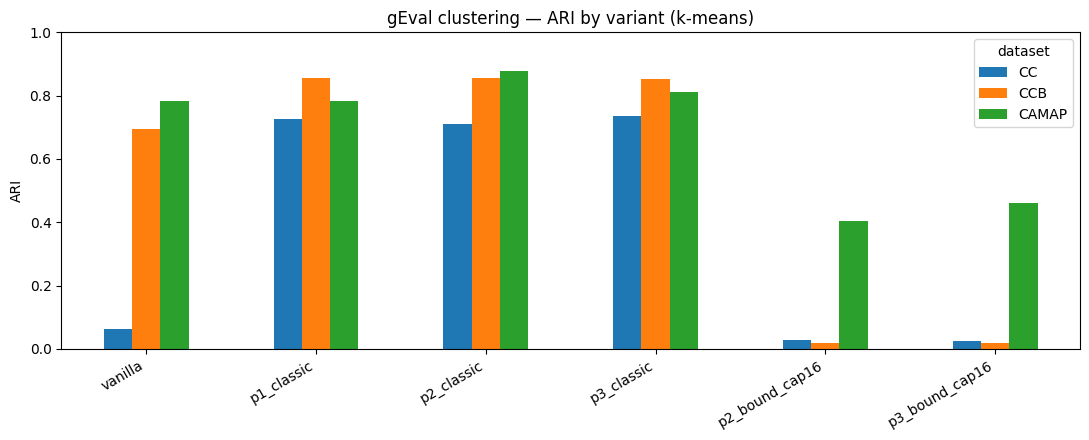

In [5]:
ax = ari.plot.bar(figsize=(11, 4.5))
ax.set_title("gEval clustering — ARI by variant (k-means)")
ax.set_ylabel("ARI"); ax.set_ylim(0, 1)
ax.legend(title="dataset"); plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.savefig(OUT / "geval_ari_by_variant.png", dpi=120); plt.show()

## Takeaways

- **MASCHInE class-mean init (`*_classic`) is the consistent winner on real-world
  clustering**: CC ~0.72–0.74, CCB ~0.85, CAMAP ~0.81–0.88 — best (or tied-best) on
  every dataset. This is the paper's P1/P2 ≫ V result, reproduced in our RDF2Vec
  setup (and `p3_classic` is the strongest on CC at 0.736).
- **Schema init helps most exactly where the hypothesis predicts.** On the
  shared-parent tasks (CC/CCB) the gap over `vanilla` is huge (CC: ~0.72 vs 0.06).
  On CAMAP, where the five classes have distinct generic parents, `vanilla` already
  reaches 0.78 and classic adds only a modest lift — schema matters less when
  co-occurrence alone already separates the classes.
- **The capped bound (`*_bound_cap16`) does not cluster.** It sits at the
  vanilla-floor on the shared-parent tasks (CC/CCB ARI ~0.02) and only partially
  recovers on the easier CAMAP (~0.40–0.46, still below classic and vanilla). The
  geometry the bound init builds is hostile to k-means — even after the norm cap
  that made it the DLCC winner. The clearest "DLCC ≠ gEval" signal on clustering.
- **Contrast with the supervised tasks.** This bound-cap collapse is *specific to
  clustering*: on classification, regression and (partly) analogies the same
  `*_bound_cap16` becomes competitive once a model — not raw k-means geometry —
  does the separating. See [[dbpedia-schema-projection-plot]] and the
  classification / regression / analogy notebooks.
- **Open question → next experiment.** All rows are *finetuned* (epoch 5). The
  init-only (frozen, epoch-0) row will say whether class-mean init already
  separates these classes or whether finetuning creates the separation.